<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Colab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9.1 Machine Learning 2 - Machine Learning Implementation to Edge Device

# Understanding and Analyzing Data

## Learning Goals

Students will be able to:

1. Implement a data collection process
2. Deploy a ML model using PyTorch
3. Build a real-time monitoring system

## 1.1 Introduction

In this lab, we will implement a machine learning model to Raspberry Pi as an application of IIoT smart monitoring system to predict running conditions of the axial flow fan (AFF). This lab is broken down into three main sections: **1) Understanding and analyzing data, 2) Machine learning implementation to Raspberry Pi**, and **3) Building up the entire monitoring system.** The entire monitoring system and the data pipeline are illustrated in Figure 1.

Note that the sample code for this lab is on [Github repo](https://github.com/purduelamm/purdue_me597_iiot/tree/main/lab/lab9/lab9_code).

<br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_update_pytorch/Lab9_fig1.png?raw=true" width="100%">

*Figure 1 Schematic of entire monitoring system and data pipeline*

## 1.2 Acceleration of the AFF


In this section, we will go over the algorithm of the smart monitoring system and determine some variables for the smart monitoring system. The goal of the monitoring system for the AFF is to visualize in real-time 1) the vibration of the AFF, 2) the execution (‘ACTIVE’ or ‘STOPPED’), and 3) the prediction of running condition (‘NORMAL’ or ‘ABNORMAL’). Obviously, the prediction of running conditions based on the machine learning model should be only done when the AFF is in an ‘ACTIVE’ state. If the AFF is not running, the prediction of anomaly does not mean anything.

The algorithm and the flowchart of the AFF monitoring system is illustrated in Figure 2. This data flow will be repeated in a loop in your program. In Lab8, we developed an anomaly detection model (autoencoder) for the second decision (“Is AFF normal?”). But we do not have a model for the first decision (“Is AFF running?”). Of course, a model to determine the running state (‘ACTIVE’ or ‘STOPPED’) can be developed by using machine learning approach as we performed in Lab8. However, let’s make the simplest rule based on the measured vibration data. The idea is that when the AFF is running, the acceleration of each axis of the sensor must increase. By a simple logic such as a certain axis acceleration is lower than a specific acceleration value, a threshold on running, we are able to determine if the AFF is running or not. In other words, if the acceleration of a certain axis is higher than the threshold value, we can say the AFF is running, e.i., ‘Execution’ of AFF is ‘ACTIVE’.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig2.png?raw=true" width="70%">

*Figure 2 Flow chart of AFF monitoring system*

The sample plots according to the various conditions of the AFF are in [Lab9 APPENDIX](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Appendix.ipynb) at the end of this manual. On the time domain plots, you see the RMS values according to the axis. As you see, when the machine is stopped (Figure A. 2), the RMS (root mean square) accelerations are the minimum on the x- and y-axis. In this example, the sample data shows that **it is reasonable to set the execution RMS threshold of the x-axis as 1 m/s<sup>2</sup>.** However, the RMS threshold value may be different according to the AFF, and the sensor configurations.

First, **deploy ADXL345 sensor to the AFF as the same to Lab8**. To determine the RMS threshold for the execution of the AFF, perform Task 1 below. If you are not sure about ADXL sensor deployment, plese review [Lab2.1 Manual](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab1.ipynb).



### Task 1.1


Run [lab9_sample1.py](https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab9/lab9_code/lab9_sample1.py) on Raspberry Pi to check the RMS values on each axis according to the executions (‘STOPPED’ and ‘ACTIVE’) of the AFF. In the AFF is the 'ACTIVE' condition, try various rotational speeds.

Determine the RMS threshold value of a specific axis.
What are the RMS value and the axis to determine if the AFF is running?



---

The X-axis was chosen to detect the AFF operation. When 'STOPPED', the X-axis RMS value remains below 0.08, but when 'ACTIVE', it increases above 0.3 depending on the rotational speed. Therefore, an RMS threshold value of 0.2 on the X-axis is determined to verify if the AFF is running.

---



### Task 1.2

Modify [lab9_sample1.py](https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab9/lab9_code/lab9_sample1.py) so that you can see the execution (running state) of the AFF.

   a. Use ‘if’ and ‘else’ statement.

   b.	The example of the result is shown in Figure 3.

   c.	By turning the AFF on and off repeatedly, confirm if your logic and the rms threshold is effective.

   d.	Attach the capture of Terminal or Thonny Shell to the report.

---

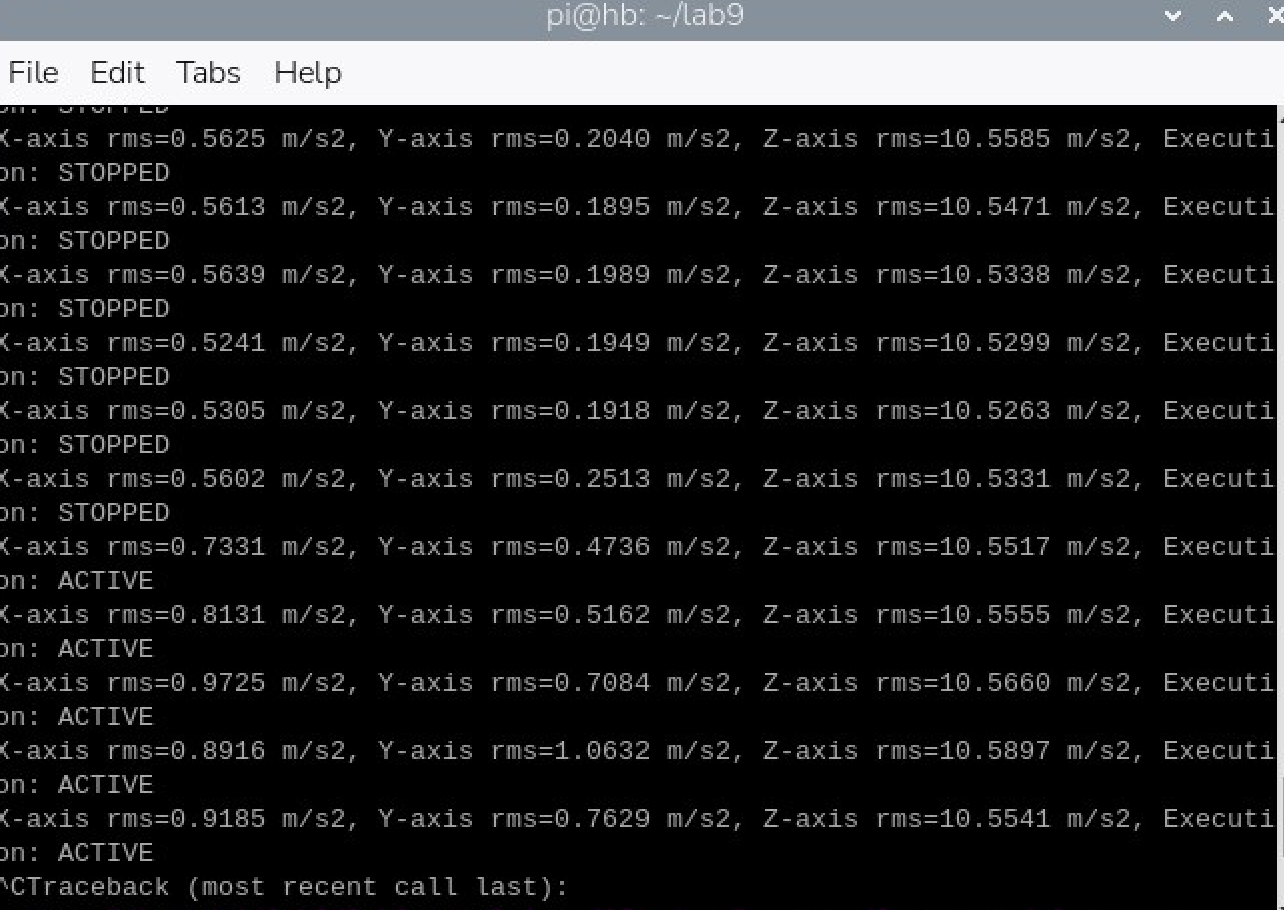

  ---

<br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig3.png?raw=true" width="100%">

*Figure 3 Check the rms values and the execution of AFF*




## 1.3 Finding Minimum and Maximum Value of your Training Data Set

In Lab9, you developed your own autoencoder model for the anomaly detection of the AFF. When training and validating the model, we used the normalized data set. Other than the threshold (MAE, mean absolute error, loss) for the autoencoder model, when you implement the model to Raspberry Pi, you need to use the minimum and the maximum to normalize the extracted features in order to employ your model. The data flow in real time to predict running conditions of the AFF is illustrated in Figure 4. To normalize the input feature, we should know the minimum and the maximum values when training. Likewise, for the anomaly detection based on the autoencoder model, we should know the MAE loss threshold.

To get the minimum and maximum values from the collected data, perform TASK 2. The [lab9_sample2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_sample2.py?raw=true) is prepared based on the training model in Lab8 to check the minimum and maximum values of the input features.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig4.png?raw=true" width="100%">


*Figure 4 Real-time data flow for machine learning model to determine running conditions of AFF*


To check the minimum and maxium values of your input feature of the training model, follow the steps below.

1.	Run [lab9_sample2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_sample2.py?raw=true) on laptop or on the code blocks below after loading your data to check the minimum and the maximum values of the extracted input feature of the model.

  a.	The collected datasets must be in the same directory as the Python script if you run the code on your laptop.
  
  b.  Upload the collected datasets on this Colab session if you run the code below.

2.	The script is incomplete as is, so you need to complete the script.

  a.	Variables you need to complete:
    * normal_data_file (line 46)
    * abnormal_data_file (line 47)
    * AXIS (line 59)
    * input_feature (line 86)



In [4]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()

# The below code block is lab9_sample2.py

Saving 20260730_135400_Normal_lab8_data.csv to 20260730_135400_Normal_lab8_data.csv
Saving 20260730_141212_Abnormal_lab8_data.csv to 20260730_141212_Abnormal_lab8_data.csv


In [3]:
import numpy as np
import pandas as pd
import torch
from scipy import stats, fft

# Time-domain data
def timeFeatures(data):
    feature = []
    for i in range(len(data)):
        mean = np.mean(data[i])                  # mean
        std = np.std(data[i])                    # standard deviation
        rms = np.sqrt(np.mean(data[i] ** 2))     # root mean square
        peak = np.max(np.abs(data[i]))           # peak
        skew = stats.skew(data[i])               # skewness
        kurt = stats.kurtosis(data[i])           # kurtosis
        cf = peak / rms if rms != 0 else 0.0     # crest factor
        feature.append(np.array([mean, std, rms, peak, skew, kurt, cf], dtype=float))
    return np.array(feature)

# DFT magnitude data
def freqFeatures(data):
    feature = []
    for i in range(len(data)):
        N = len(data[i])
        yf = 2 / N * np.abs(fft.fft(data[i])[:N // 2])  # DFT magnitude
        yf[0] = 0
        feature.append(np.array(yf, dtype=float))
    return np.array(feature)

def tensorNormalization(data):
    data = np.asarray(data, dtype=np.float32)
    data_t = torch.tensor(data, dtype=torch.float32)

    min_val = torch.min(data_t)
    max_val = torch.max(data_t)

    data_normal = (data_t - min_val) / (max_val - min_val + 1e-8)

    minVal = min_val.item()
    maxVal = max_val.item()

    return data_normal, minVal, maxVal  # torch tensor, min, max

## data loading
# All files should be in the same directory (folder)
normal_data_file = "20260730_135400_Normal_lab8_data.csv"      # normal condition filename: You must change this
abnormal_data_file = "20260730_141212_Abnormal_lab8_data.csv"    # abnormal condition filename: You must change this

df_normal = pd.read_csv(normal_data_file)
df_abnormal = pd.read_csv(abnormal_data_file)

frames = [df_normal, df_abnormal]
df = pd.concat(frames, ignore_index=True)

## Data Transformation
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
AXIS = 'Xacc array [m/s2]'   # Select one of the above axes

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat(
    [df['Condition'], df[AXIS].str.split(' ', expand=True).astype(float)],
    axis=1
)
ds = df_new.copy()

# Converting the classifier into binary values
ds.loc[df['Condition'] == 'Normal', 'Status'] = 1
ds.loc[df['Condition'] == 'Abnormal', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

data = ds.values

# Define raw data without signal processing
raw_data = data[:, :-1].astype(np.float32)

# Labels: the last column
labels = data[:, -1].astype(np.float32)

time_data = timeFeatures(raw_data)
freq_data = freqFeatures(raw_data)

## Data (feature) selection
# Choose one: raw_data, time_data, or freq_data
input_feature = raw_data

# Normalize once and print min/max
input_feature_normalized, min_feature, max_feature = tensorNormalization(input_feature)

print("The minimum is {} and the maximum is {}.".format(min_feature, max_feature))

KeyError: 'Condition'

### Task 1.3 Answer the questions below regarding your machine learning feature and threshold.

1. What is the input feature? (Axis and type of feture among raw, time feature, frequency feature)



---

Write down your answer to 1.

---



2. What is the minimum value of the input feature?



---

Write down your answer to 2.

---



3. What is the maximum value of the input feature?



---

Write down your answer to 3.

---



4. What is the threshold (MAE loss) value from Lab8 for the best trained model?



---

Write down your answer to 4.

---



<br></br>

Please continue to [Lab 9.2 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Colab2.ipynb).
